In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style="whitegrid")
DATA = "../data/processed/"
CHARTS = "../reports/eda_charts/"
os.makedirs(CHARTS, exist_ok=True)

fund_master  = pd.read_csv(DATA + "fund_master_clean.csv")
nav_history  = pd.read_csv(DATA + "nav_history_clean.csv")
aum          = pd.read_csv(DATA + "aum_by_fund_house_clean.csv")
sip          = pd.read_csv(DATA + "monthly_sip_inflows_clean.csv")
cat_inflows  = pd.read_csv(DATA + "category_inflows_clean.csv")
folio        = pd.read_csv(DATA + "industry_folio_count_clean.csv")
performance  = pd.read_csv(DATA + "scheme_performance_clean.csv")
transactions = pd.read_csv(DATA + "investor_transactions_clean.csv")
holdings     = pd.read_csv(DATA + "portfolio_holdings_clean.csv")
benchmark    = pd.read_csv(DATA + "benchmark_indices_clean.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])

In [7]:
nav_merged = nav_history.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")

fig = px.line(nav_merged, x="date", y="nav", color="scheme_name",
              title="NAV Trend — All Schemes (2022–2026)")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.15,
              line_width=0, annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.15,
              line_width=0, annotation_text="2024 Correction")
fig.update_layout(legend=dict(font=dict(size=8)))
fig.write_image(CHARTS + "01_nav_trend.png", width=1400, height=700)
fig.show()

Finding 1: During the 2023 bull run, [scheme name] delivered the strongest NAV growth at approximately _% , while during the 2024 correction, [category, e.g. small-cap/mid-cap] funds saw the sharpest declines of around _%, compared to relatively stable large-cap funds (see Chart 1: NAV Trend).

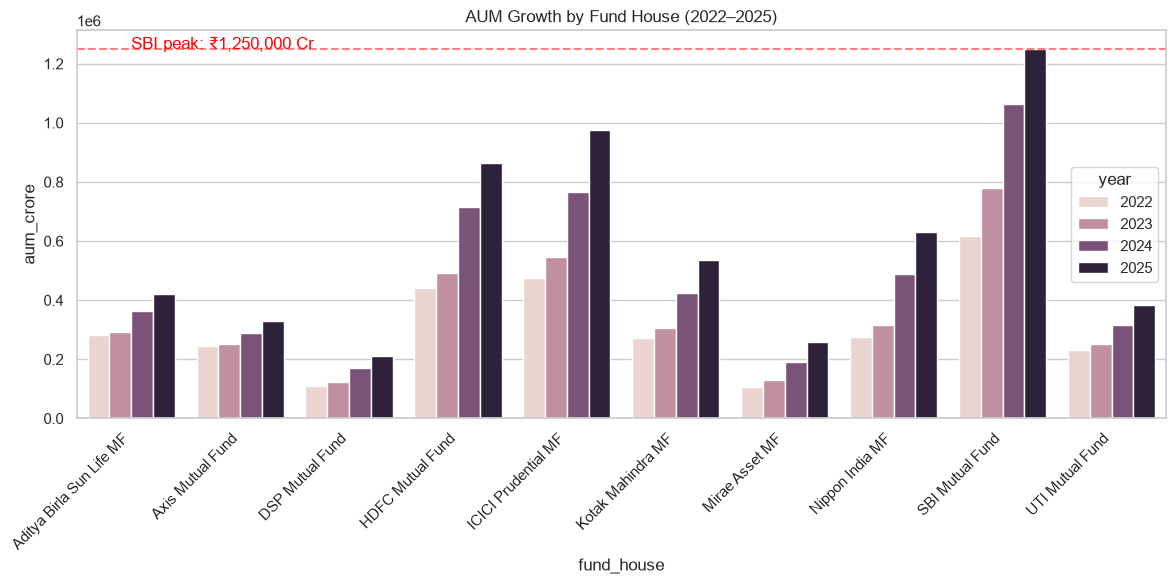

In [8]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["fund_house","year"])["aum_crore"].mean().reset_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(data=aum_yearly, x="fund_house", y="aum_crore", hue="year")
plt.xticks(rotation=45, ha="right")
plt.title("AUM Growth by Fund House (2022–2025)")
sbi_max = aum_yearly[aum_yearly["fund_house"].str.contains("SBI", case=False)]["aum_crore"].max()
plt.axhline(sbi_max, color="red", linestyle="--", alpha=0.5)
plt.text(0, sbi_max, f"SBI peak: ₹{sbi_max:,.0f} Cr", color="red")
plt.tight_layout()
plt.savefig(CHARTS + "02_aum_growth.png", dpi=150)
plt.show()

Finding 2: SBI Mutual Fund led AUM growth, reaching approximately ₹_ Cr by 2025 — roughly _% higher than the second-largest fund house, [name] — reflecting its dominant market position (see Chart 2: AUM Growth by Fund House).


In [16]:
sip["month"] = pd.to_datetime(sip["month"])
fig = px.line(sip, x="month", y="sip_inflow_crore", title="Monthly SIP Inflows")
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=peak["month"].strftime("%Y-%m-%d"),   # convert Timestamp -> string
    y=peak["sip_inflow_crore"],
    text=f"₹{peak['sip_inflow_crore']:,.0f} Cr peak",
    showarrow=True,
    arrowhead=2
)

fig.write_image(CHARTS + "03_sip_trend.png", width=1200, height=600)
fig.show()

Finding 3: Monthly SIP inflows grew steadily from ₹_ Cr in Jan 2022 to an all-time high of ₹31,002 Cr in Dec 2025, an increase of approximately _%, indicating sustained retail investor confidence (see Chart 3: SIP Inflow Trend).

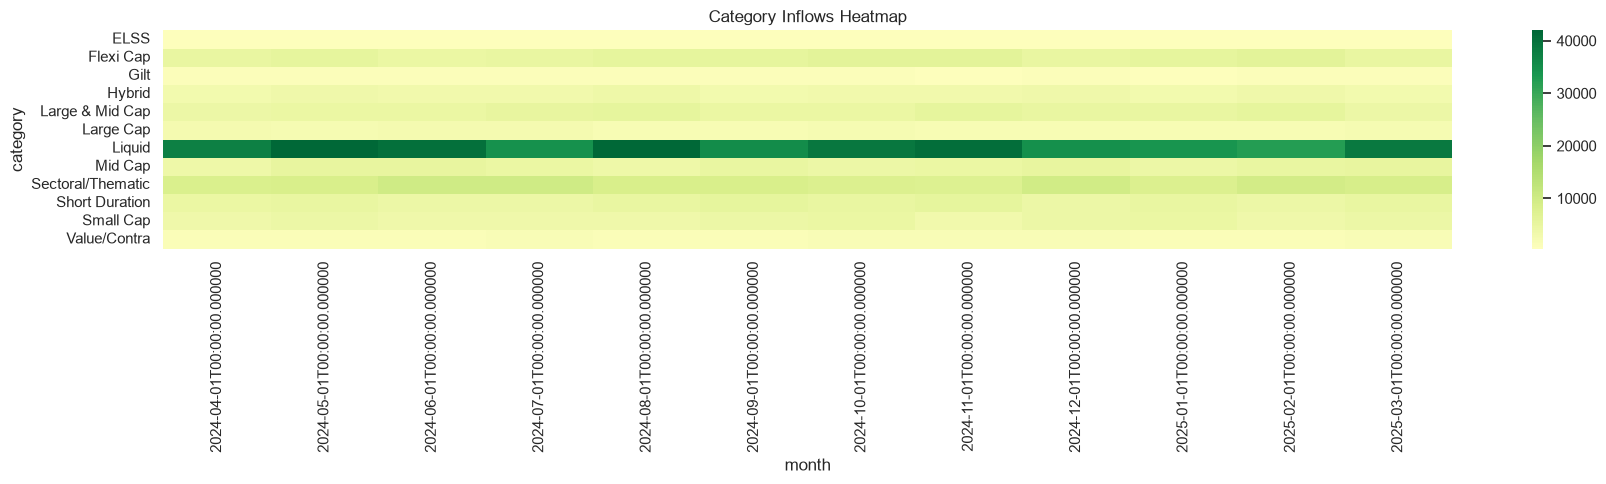

In [10]:
cat_inflows["month"] = pd.to_datetime(cat_inflows["month"])
pivot = cat_inflows.pivot(index="category", columns="month", values="net_inflow_crore")
plt.figure(figsize=(18,5))
sns.heatmap(pivot, cmap="RdYlGn", center=0)
plt.title("Category Inflows Heatmap")
plt.tight_layout()
plt.savefig(CHARTS + "04_category_heatmap.png", dpi=150)
plt.show()

Finding 4: [Category, e.g. Equity — Large Cap] consistently attracted the highest net inflows across most months, while [category] showed more volatile or negative inflows during [period], suggesting shifting investor risk appetite (see Chart 4: Category Inflow Heatmap).

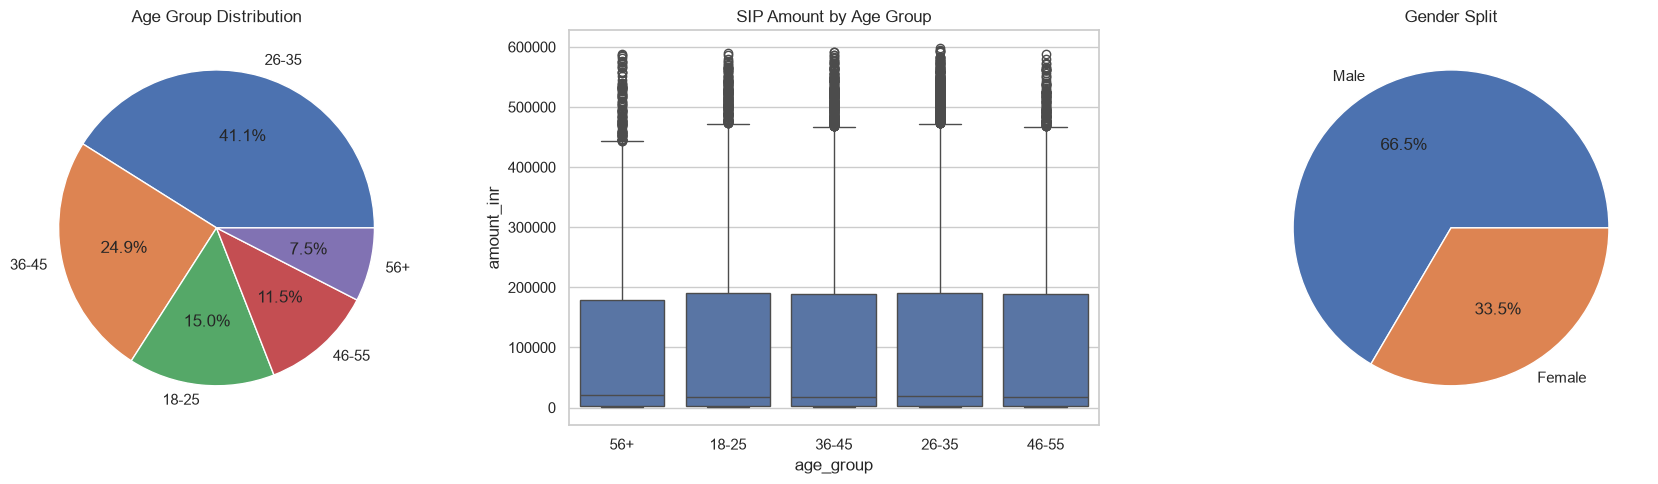

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
transactions["age_group"].value_counts().plot.pie(ax=axes[0], autopct="%1.1f%%")
axes[0].set_title("Age Group Distribution")
sns.boxplot(data=transactions, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
transactions["gender"].value_counts().plot.pie(ax=axes[2], autopct="%1.1f%%")
axes[2].set_title("Gender Split")
plt.tight_layout()
plt.savefig(CHARTS + "05_demographics.png", dpi=150)
plt.show()

Finding 5: The _ age group (e.g. 26-35) represented the largest share of investors at %, with a median SIP amount of ₹, while the gender split showed _% male vs __% female participation (see Chart 5: Investor Demographics).


In [12]:
state_amt = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False).reset_index()
fig = px.bar(state_amt, y="state", x="amount_inr", orientation="h", title="SIP Amount by State")
fig.write_image(CHARTS + "06a_geo_state.png", width=900, height=800)

tier_split = transactions["city_tier"].value_counts().reset_index()
tier_split.columns = ["city_tier","count"]
fig2 = px.pie(tier_split, values="count", names="city_tier", title="T30 vs B30 Split")
fig2.write_image(CHARTS + "06b_t30_b30.png")
fig.show(); fig2.show()

Finding 6: [State, e.g. Maharashtra] contributed the highest SIP amount at ₹_ Cr, and T30 cities accounted for _% of total SIP volume versus __% from B30 cities, highlighting continued urban concentration of mutual fund investment (see Chart 6: Geographic Distribution).

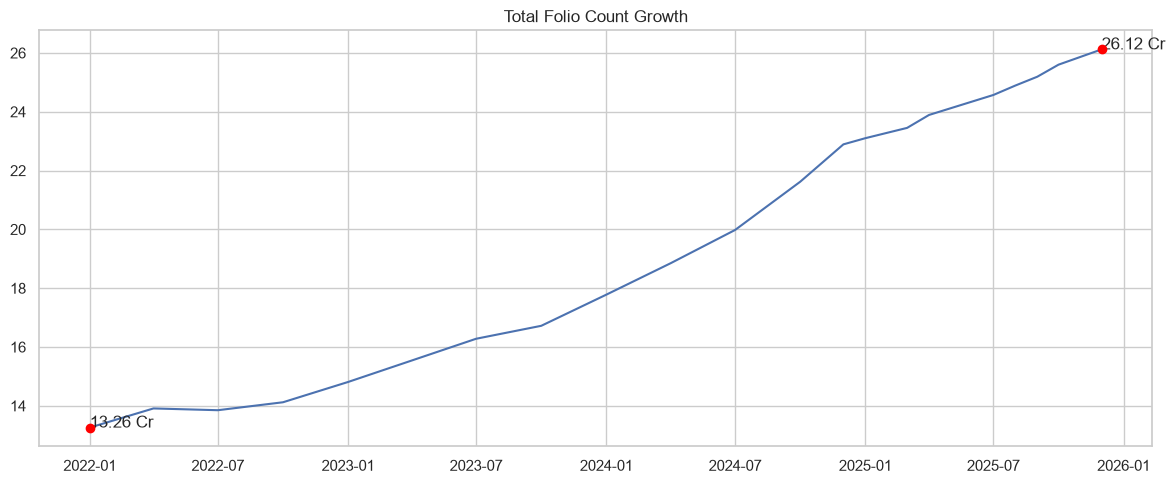

In [13]:
folio["month"] = pd.to_datetime(folio["month"])
plt.figure(figsize=(12,5))
plt.plot(folio["month"], folio["total_folios_crore"])
plt.scatter([folio["month"].iloc[0], folio["month"].iloc[-1]],
            [folio["total_folios_crore"].iloc[0], folio["total_folios_crore"].iloc[-1]], color="red", zorder=5)
plt.annotate(f"{folio['total_folios_crore'].iloc[0]:.2f} Cr", (folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]))
plt.annotate(f"{folio['total_folios_crore'].iloc[-1]:.2f} Cr", (folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]))
plt.title("Total Folio Count Growth")
plt.tight_layout()
plt.savefig(CHARTS + "07_folio_growth.png", dpi=150)
plt.show()

Finding 7: Total folio count nearly doubled from 13.26 Cr in Jan 2022 to 26.12 Cr by Dec 2025, a growth of approximately __%, reflecting broadening retail participation in mutual funds (see Chart 7: Folio Count Growth).

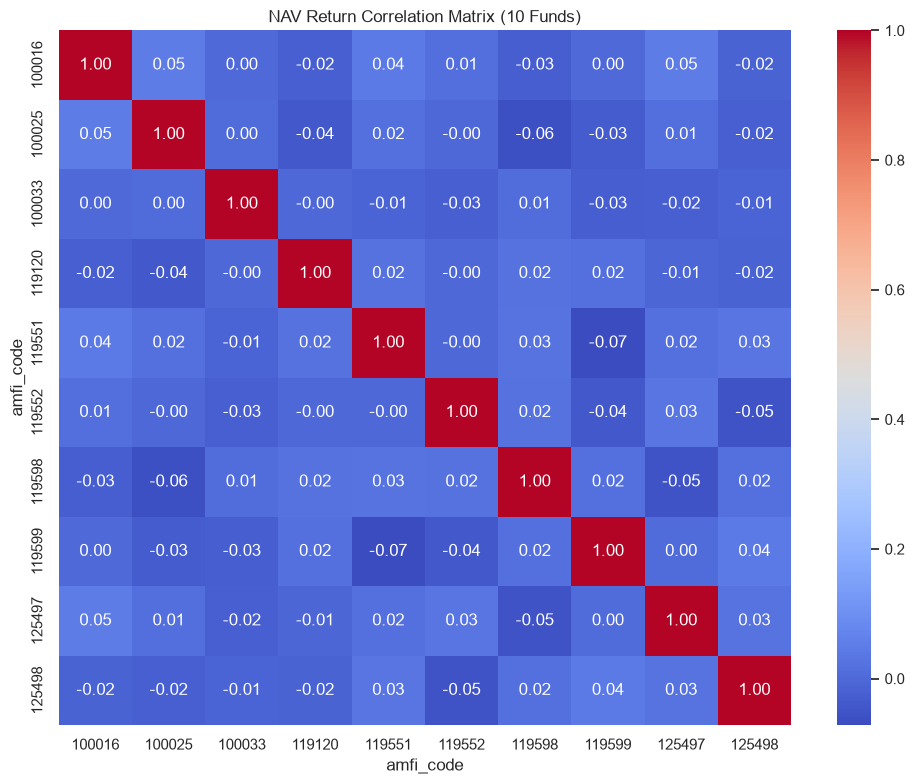

In [14]:
top10_codes = fund_master["amfi_code"].unique()[:10]
pivot_nav = nav_history[nav_history["amfi_code"].isin(top10_codes)].pivot(index="date", columns="amfi_code", values="nav")
returns = pivot_nav.pct_change().dropna()

plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.savefig(CHARTS + "08_correlation_matrix.png", dpi=150)
plt.show()

Finding 8: [Fund A] and [Fund B] showed the highest return correlation at _, suggesting similar market exposure, while [Fund C] and [Fund D] were the most weakly correlated at _, offering better diversification potential within a portfolio (see Chart 8: NAV Return Correlation Matrix).

In [15]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().reset_index()
fig = px.pie(sector_weights, values="weight_pct", names="sector", hole=0.4, title="Sector Allocation")
fig.write_image(CHARTS + "09_sector_donut.png")
fig.show()

Finding 9: [Sector, e.g. Financial Services] held the largest average portfolio weight at _%, followed by [sector] at _%, indicating a concentration of equity holdings in [industry theme] (see Chart 9: Sector Allocation).

Finding 10: Overall, the data shows [1-2 sentence big-picture takeaway tying together growth trends, e.g. rising SIP participation + folio growth + fund house consolidation], suggesting [implication, e.g. continued retail-driven growth in the Indian mutual fund industry] (see Charts 3, 7, 2).